In [ ]:
# 분포(Distribution) — histplot, kdeplot, ecdfplot, rugplot, displot
# 관계형(Relational) — scatterplot, lineplot, relplot
# 범주형(Categorical) — barplot, countplot, boxplot, violinplot, stripplot, swarmplot, pointplot, catplot
# 회귀(Regression) — regplot, lmplot, residplot
# 행렬(Matrix) — heatmap, clustermap
# 다변량(Multivariate) — pairplot, PairGrid, FacetGrid, jointplot

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [4]:
# Windows 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

In [5]:
df_tips = sns.load_dataset("tips")
df_titanic = sns.load_dataset("titanic")
df_penguins = sns.load_dataset("penguins")
df_flights = sns.load_dataset("flights")

In [ ]:
# pairgrid를 간단하게 쓸 수 있게 한 것이 pairplot

# pairgrid는 대각선/상삼각/하삼각을 각각 다르게 지정 가능

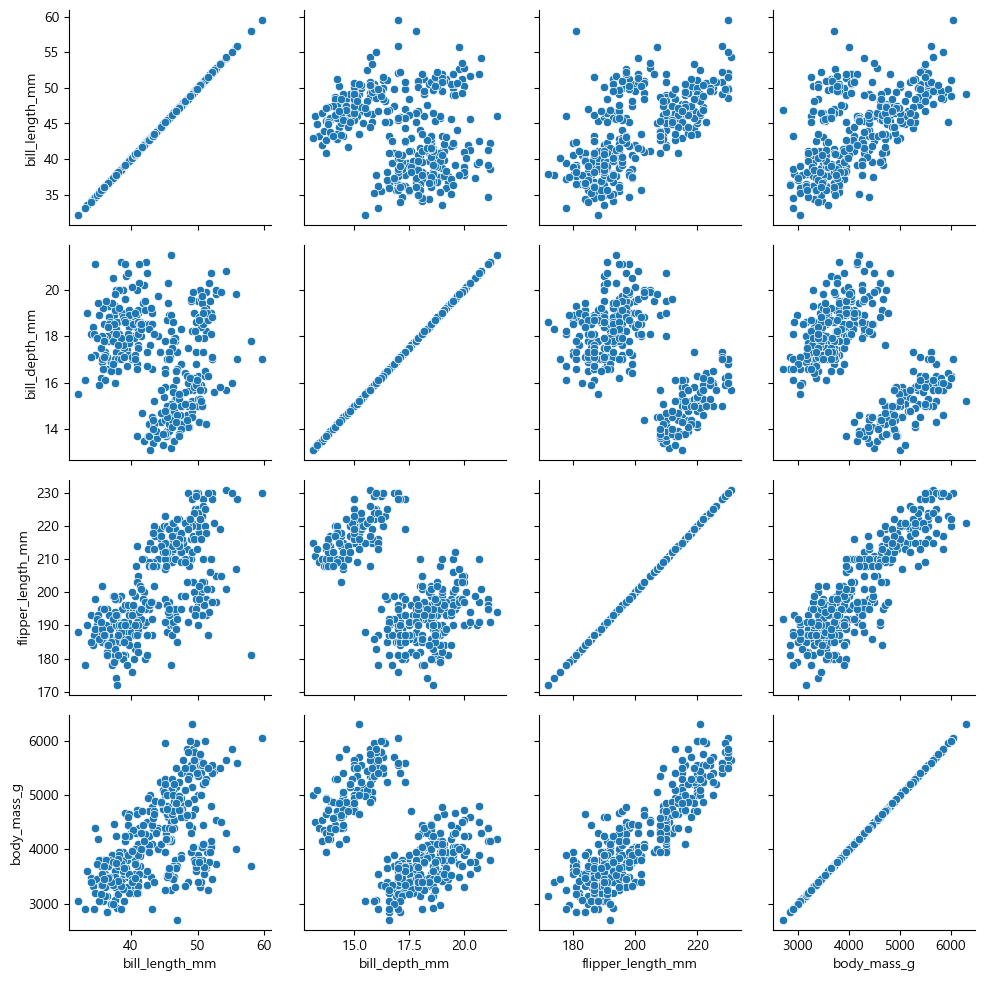

In [6]:
# 다변량(Multivariate) — PairGrid

# 기본 PairGrid
g = sns.PairGrid(df_penguins)
g.map(sns.scatterplot)
plt.show()

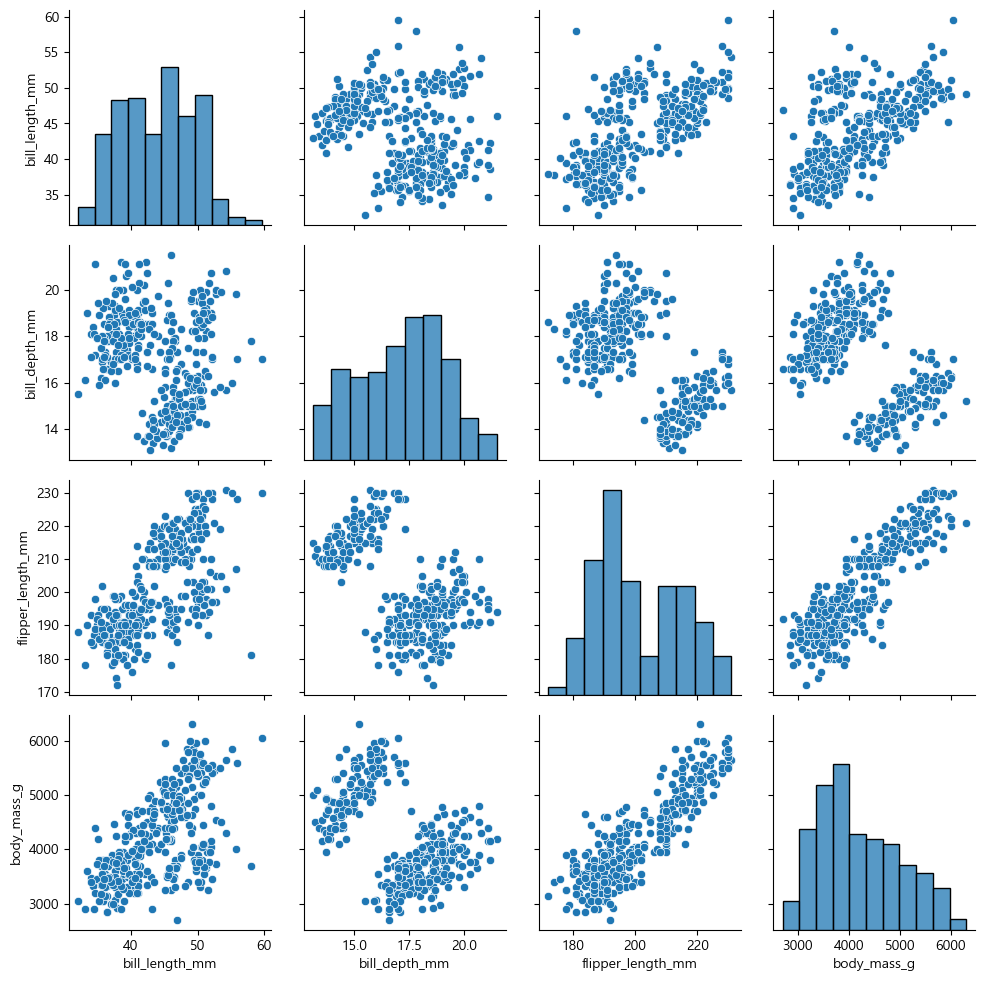

In [7]:
# 다변량(Multivariate) — PairGrid

# map_diag + map_offdiag
g = sns.PairGrid(df_penguins)
g.map_diag(sns.histplot)
g.map_offdiag(sns.scatterplot)
plt.show()

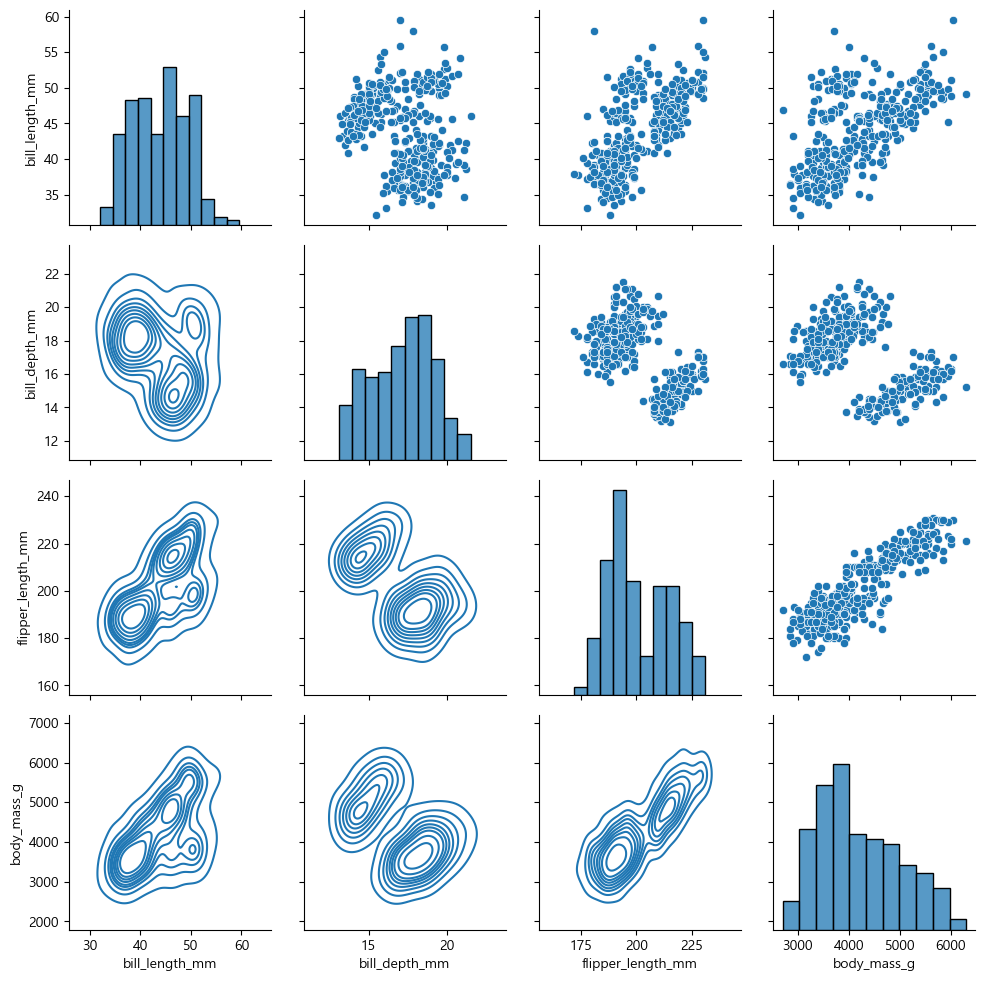

In [8]:
# 다변량(Multivariate) — PairGrid

# map_upper + map_lower + map_diag
g = sns.PairGrid(df_penguins)
g.map_diag(sns.histplot)
g.map_upper(sns.scatterplot)
g.map_lower(sns.kdeplot)
plt.show()

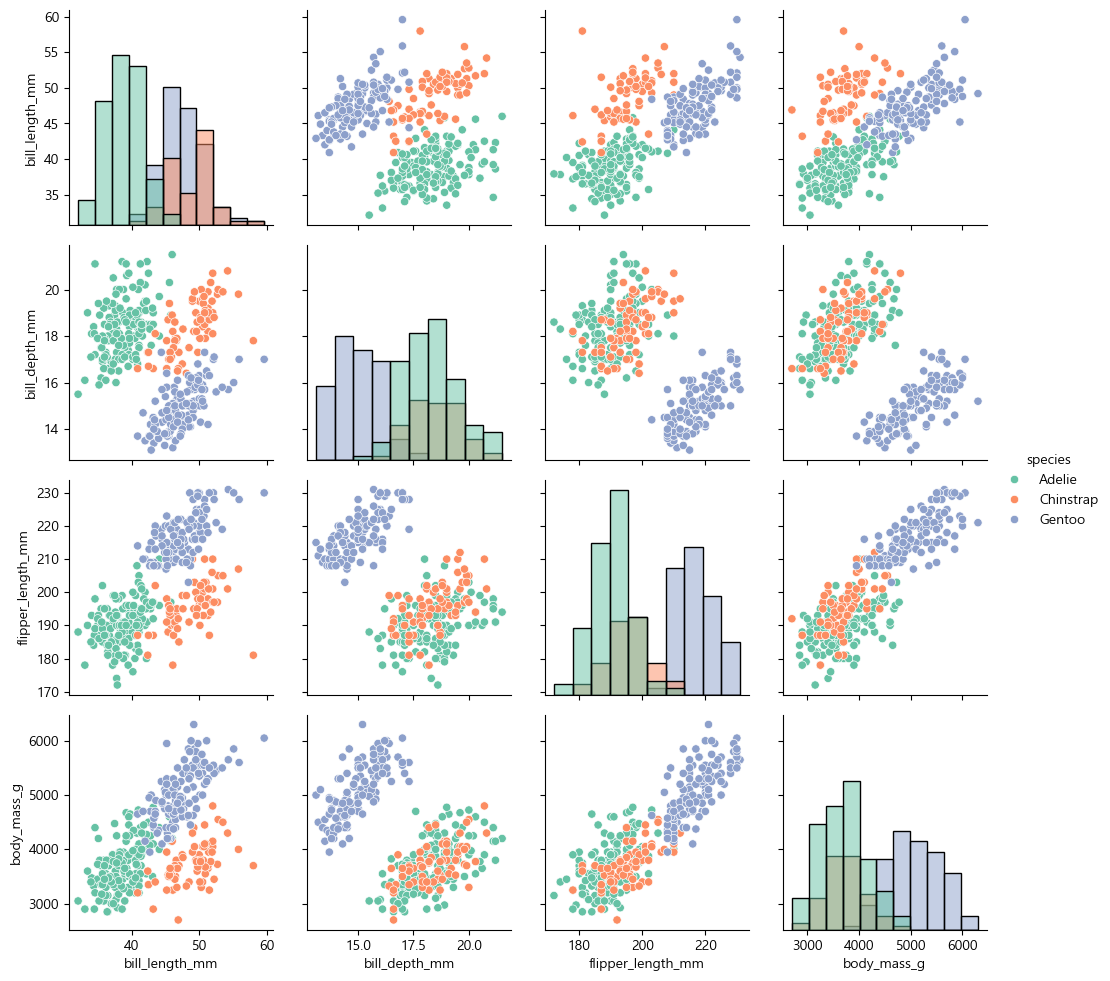

In [9]:
# 다변량(Multivariate) — PairGrid

# hue + palette
g = sns.PairGrid(df_penguins, hue="species", palette="Set2")
g.map_diag(sns.histplot)
g.map_offdiag(sns.scatterplot)
g.add_legend()
plt.show()

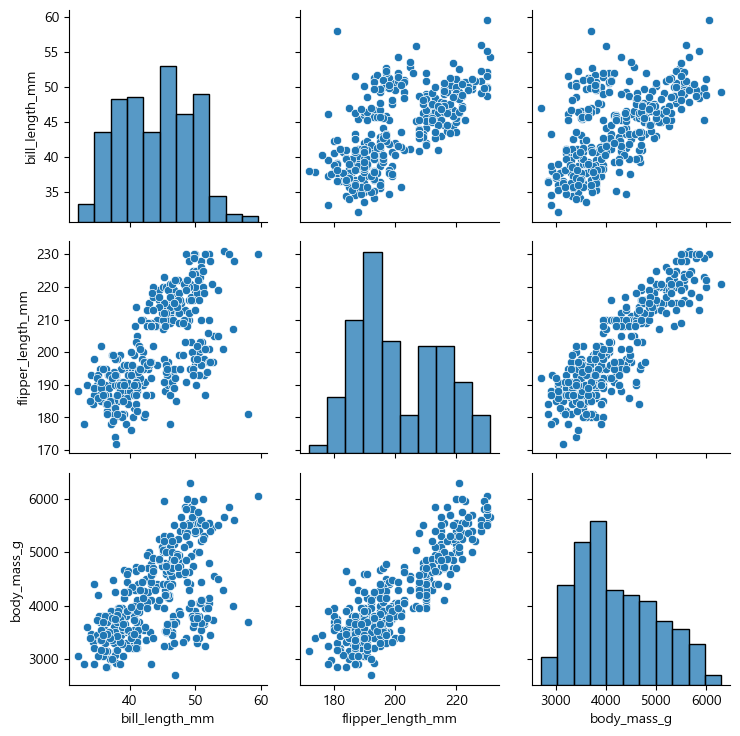

In [10]:
# 다변량(Multivariate) — PairGrid

# vars — 특정 컬럼만 선택
g = sns.PairGrid(df_penguins,
                 vars=["bill_length_mm", "flipper_length_mm", "body_mass_g"])
g.map_diag(sns.histplot)
g.map_offdiag(sns.scatterplot)
plt.show()

In [ ]:
# FacetGrid
# FacetGrid로 격자 구조를 만들고 map 함수로 그래프를 지정하는 방식
# 격자 구조를 만들면서 데이터를 할당
# relplot, catplot, displot의 col, row가 내부적으로 FacetGrid를 사용?

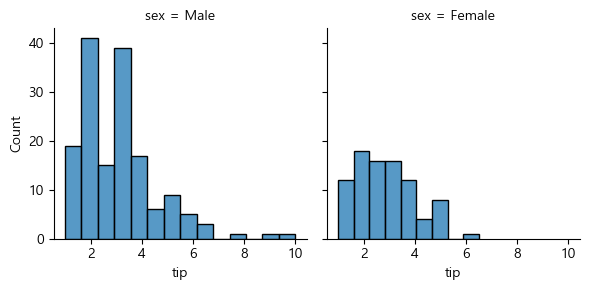

In [12]:
# 다변량(Multivariate) — FacetGrid

# 기본 FacetGrid (col)
g = sns.FacetGrid(df_tips, col="sex")   # df_tips의 sex 컬럼의 고유값을 기준으로 열을 나눈 빈 subplot을 생성
g.map(sns.histplot, "tip")              # 각 subplot에 x="tip"으로 sns.histplot을 그림
plt.show()

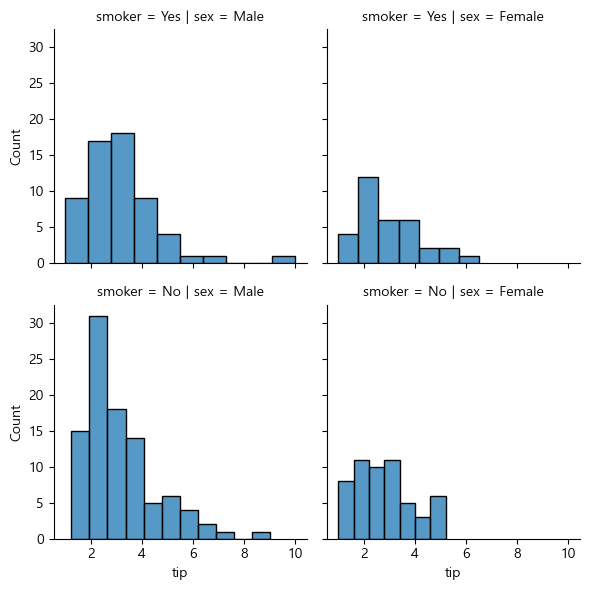

In [13]:
# 다변량(Multivariate) — FacetGrid

# col + row
g = sns.FacetGrid(df_tips, col="sex", row="smoker")
# df_tips 데이터의
# sex 컬럼의 고유값을 기준으로 열, smoker 컬럼의 고유값을 기준으로 행을 나눈 2행 2열의 빈 subplot을 생성

g.map(sns.histplot, "tip")
# 4개의 각 subplot에 x="tip"으로 sns.histplot을 그림
plt.show()

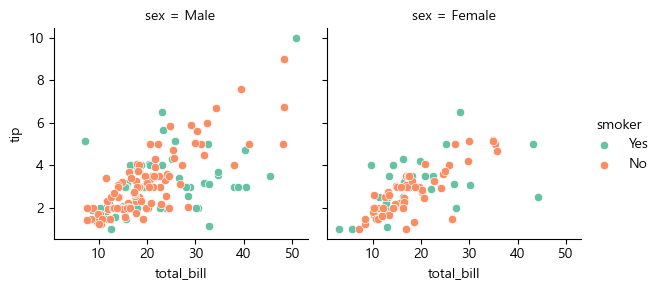

In [14]:
# 다변량(Multivariate) — FacetGrid

# hue + palette
g = sns.FacetGrid(df_tips, col="sex", hue="smoker", palette="Set2")
g.map(sns.scatterplot, "total_bill", "tip")     # 4개의 각 subplot에 x="total_bill", y="tip"으로 sns.scatterplot을 그림
g.add_legend()                                  # legend의 대상은 hue, style, size
plt.show()

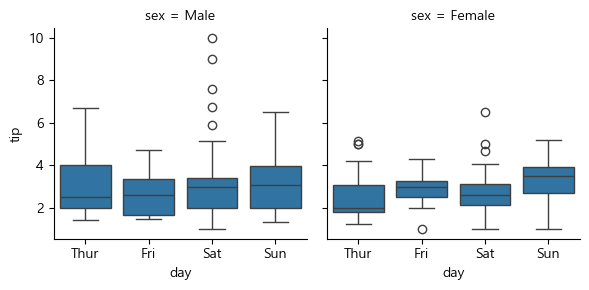

In [15]:
# 다변량(Multivariate) — FacetGrid

# map 함수를 sns.boxplot로 변경
g = sns.FacetGrid(df_tips, col="sex")
g.map(sns.boxplot, "day", "tip", order=["Thur", "Fri", "Sat", "Sun"])
plt.show()

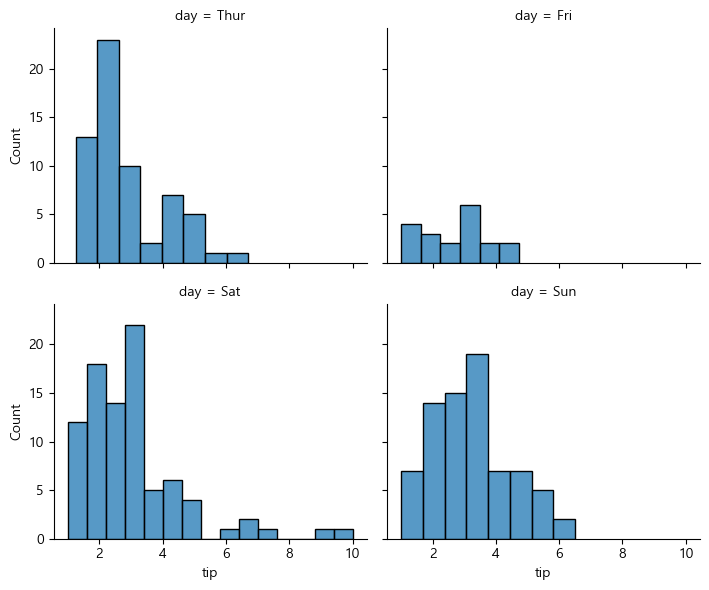

In [19]:
# 다변량(Multivariate) — FacetGrid

# col_wrap + height + aspect
g = sns.FacetGrid(df_tips, col="day", col_wrap=2, height=3, aspect=1.2)
# day: 고유값 기준으로 열 방향 subplot 생성 (4개)
# col_wrap=2: 한 행에 최대 2개까지만 배치, 넘으면 줄바꿈 칼럼에 일정 길이 제한을 걸어두고 그걸 넘으면 아래로 내려라
# height=3: 각 subplot의 높이 (인치)
# aspect=1.2: 각 subplot의 가로/세로 비율 (너비 = height × aspect)
# 따라서 너비는 height × aspect =3 x 1.2 = 3.6인치

g.map(sns.histplot, "tip")
plt.show()

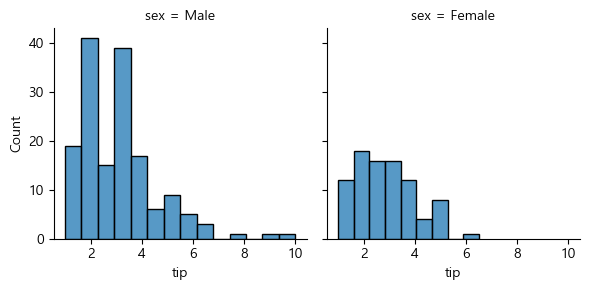

In [20]:
# 다변량(Multivariate) — FacetGrid

# sharex + sharey — 축 공유 비교
# True (기본) → 모든 subplot이 같은 축 범위 사용
g = sns.FacetGrid(df_tips, col="sex", sharex=True, sharey=True)
g.map(sns.histplot, "tip")
plt.show()


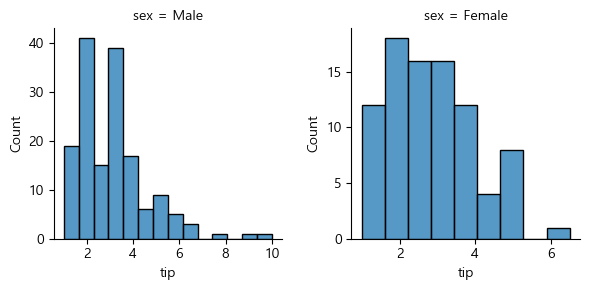

In [21]:

# False → 각 subplot이 독립적인 축 범위 사용
g = sns.FacetGrid(df_tips, col="sex", sharex=False, sharey=False)
g.map(sns.histplot, "tip")
plt.show()